# Análisis de errores de la rama textual. Mejor modelo: GRU

## Carga de datos y creación de DF de resultados

In [1]:
# Crear DF a partir de resultados de validación greedy y rescoring
import pickle
import json
from pathlib import Path
import pandas as pd
import numpy as np

# ----------------------------
# Rutas
# ----------------------------
PKL_PATH = Path(r"\\wsl.localhost\Ubuntu\home\lucas\projects\mamba_experiment\gru_text\trained_models\gru_text\checkpoint\val_metrics.pkl")
JSON_PATH = Path(r"\\wsl.localhost\Ubuntu\home\lucas\projects\mamba_experiment\gru_text\rescoring_results\alpha_sweep_gpt2xl_bw100\text_gpt2xl_bw100_a12.json")

# ----------------------------
# Cargar pickle
# ----------------------------
with open(PKL_PATH, "rb") as f:
    val_metrics = pickle.load(f)

print("Keys val_metrics:", val_metrics.keys())

# ----------------------------
# Función para aplanar listas por batch
# ----------------------------
def flatten_val_metrics(val_metrics_dict):
    rows = []

    n_batches = len(val_metrics_dict["true_text"])

    for b in range(n_batches):
        true_batch = val_metrics_dict["true_text"][b]
        dec_batch = val_metrics_dict["decoded_text"][b]
        raw_batch = val_metrics_dict.get("raw_text", [None] * n_batches)[b]
        day_batch = val_metrics_dict.get("day_indicies", [None] * n_batches)[b]
        block_batch = val_metrics_dict.get("block_nums", [None] * n_batches)[b]
        trial_batch = val_metrics_dict.get("trial_nums", [None] * n_batches)[b]
        char_len_batch = val_metrics_dict.get("char_seq_lens", [None] * n_batches)[b]

        batch_size = len(true_batch)

        for i in range(batch_size):
            row = {
                "batch_idx": b,
                "sample_idx_in_batch": i,
                "true_text": true_batch[i] if i < len(true_batch) else None,
                "decoded_text": dec_batch[i] if i < len(dec_batch) else None,
                "raw_text": raw_batch[i] if raw_batch is not None and i < len(raw_batch) else None,
                "day_index": int(day_batch[i]) if day_batch is not None and i < len(day_batch) else None,
                "block_num": int(block_batch[i]) if block_batch is not None and i < len(block_batch) else None,
                "trial_num": int(trial_batch[i]) if trial_batch is not None and i < len(trial_batch) else None,
                "char_seq_len": int(char_len_batch[i]) if char_len_batch is not None and i < len(char_len_batch) else None,
            }
            rows.append(row)

    return pd.DataFrame(rows)

df_val = flatten_val_metrics(val_metrics)
print("df_val shape:", df_val.shape)
display(df_val.head())

# ----------------------------
# Cargar json de rescoring
# ----------------------------
with open(JSON_PATH, "r", encoding="utf-8") as f:
    rescoring_data = json.load(f)

print("Keys rescoring json:", rescoring_data.keys())
print("Global results:", rescoring_data["results"])

df_rescore = pd.DataFrame(rescoring_data["examples"])
print("df_rescore shape:", df_rescore.shape)
display(df_rescore.head())

Keys val_metrics: dict_keys(['logits', 'n_time_steps', 'decoded_text', 'true_text', 'char_seq_lens', 'losses', 'block_nums', 'trial_nums', 'day_indicies', 'raw_text', 'day_metrics', 'avg_CER', 'avg_WER', 'avg_loss'])
df_val shape: (1426, 9)


,batch_idx,sample_idx_in_batch,true_text,decoded_text,raw_text,day_index,block_num,trial_num,char_seq_len
0,0,0,you can see the code at this point as well.,you can see ne cold at this point as well.,you can see the code at this point as well.,1,8,0,43
1,0,1,how does it keep the cost down?,how douest it keep the cost dyvet.,how does it keep the cost down?,1,8,1,31
2,0,2,not too controversial.,not two contforfusial.,not too controversial.,1,8,2,22
3,0,3,the jury and a judge work together on it.,the tury and a jhrush work together on it.,the jury and a judge work together on it.,1,8,3,41
4,0,4,were quite vocal about it.,were quite focul about it.,were quite vocal about it.,1,8,4,26


Keys rescoring json: dict_keys(['results', 'examples', 'config'])
Global results: {'greedy': {'CER': 0.15450246710526316, 'WER': 0.3313922710428798, 'total_char_length': 48640, 'total_word_length': 9445}, 'beam': {'CER': 0.15244654605263158, 'WER': 0.32948650079407094, 'total_char_length': 48640, 'total_word_length': 9445}, 'beam_lm': {'CER': 0.1341077302631579, 'WER': 0.262572789835892, 'total_char_length': 48640, 'total_word_length': 9445}}
df_rescore shape: (1426, 7)


,batch_idx,sample_idx_in_batch,true_text,greedy_text,beam_text,beam_lm_text,nbest
0,0,0,you can see the code at this point as well.,you can see ne cold at this point as well.,you can see ne cold at this point as well.,you can see the cold at this point as well.,[{'text': 'you can see ne cold at this point a...
1,0,1,how does it keep the cost down?,how douest it keep the cost dyvet.,how doest it keep the cost dyvet.,how doest it keep the cost govt.,"[{'text': 'how doest it keep the cost dyvet.',..."
2,0,2,not too controversial.,not two contforfusial.,not two contforfusial.,not to conforfusial.,"[{'text': 'not two contforfusial.', 'ctc_score..."
3,0,3,the jury and a judge work together on it.,the tury and a jhrush work together on it.,the tury and a jhush work together on it.,the tury and a thrush work together on it.,[{'text': 'the tury and a jhush work together ...
4,0,4,were quite vocal about it.,were quite focul about it.,were quite focul about it.,were quite foul about it.,"[{'text': 'were quite focul about it.', 'ctc_s..."


In [2]:
# Unir val_metrics y rescoring por batch y posición dentro del batch
df_text = df_rescore.merge(
    df_val,
    on=["batch_idx", "sample_idx_in_batch"],
    how="left",
    suffixes=("_rescore", "_val")
)

print("df_text shape:", df_text.shape)
display(df_text.head())

df_text shape: (1426, 14)


,batch_idx,sample_idx_in_batch,true_text_rescore,greedy_text,beam_text,beam_lm_text,nbest,true_text_val,decoded_text,raw_text,day_index,block_num,trial_num,char_seq_len
0,0,0,you can see the code at this point as well.,you can see ne cold at this point as well.,you can see ne cold at this point as well.,you can see the cold at this point as well.,[{'text': 'you can see ne cold at this point a...,you can see the code at this point as well.,you can see ne cold at this point as well.,you can see the code at this point as well.,1,8,0,43
1,0,1,how does it keep the cost down?,how douest it keep the cost dyvet.,how doest it keep the cost dyvet.,how doest it keep the cost govt.,"[{'text': 'how doest it keep the cost dyvet.',...",how does it keep the cost down?,how douest it keep the cost dyvet.,how does it keep the cost down?,1,8,1,31
2,0,2,not too controversial.,not two contforfusial.,not two contforfusial.,not to conforfusial.,"[{'text': 'not two contforfusial.', 'ctc_score...",not too controversial.,not two contforfusial.,not too controversial.,1,8,2,22
3,0,3,the jury and a judge work together on it.,the tury and a jhrush work together on it.,the tury and a jhush work together on it.,the tury and a thrush work together on it.,[{'text': 'the tury and a jhush work together ...,the jury and a judge work together on it.,the tury and a jhrush work together on it.,the jury and a judge work together on it.,1,8,3,41
4,0,4,were quite vocal about it.,were quite focul about it.,were quite focul about it.,were quite foul about it.,"[{'text': 'were quite focul about it.', 'ctc_s...",were quite vocal about it.,were quite focul about it.,were quite vocal about it.,1,8,4,26


In [4]:
# Calcular CER y WER
import re

def normalize_text_for_error_analysis(text):
    if text is None:
        return ""
    text = str(text).lower().strip()
    text = text.replace(">", "")
    text = re.sub(r"[^\w\s]", "", text)  # elimina puntuación
    text = " ".join(text.split())
    return text

def levenshtein_tokens(ref, hyp):
    # Devuelve distancia de edición simple
    n, m = len(ref), len(hyp)
    dp = [[0]*(m+1) for _ in range(n+1)]

    for i in range(n+1):
        dp[i][0] = i
    for j in range(m+1):
        dp[0][j] = j

    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = 0 if ref[i-1] == hyp[j-1] else 1
            dp[i][j] = min(
                dp[i-1][j] + 1,      # borrado
                dp[i][j-1] + 1,      # inserción
                dp[i-1][j-1] + cost  # sustitución / match
            )
    return dp[n][m]

def cer(ref, hyp):
    ref = list(normalize_text_for_error_analysis(ref))
    hyp = list(normalize_text_for_error_analysis(hyp))
    return levenshtein_tokens(ref, hyp) / max(len(ref), 1)

def wer(ref, hyp):
    ref = normalize_text_for_error_analysis(ref).split()
    hyp = normalize_text_for_error_analysis(hyp).split()
    return levenshtein_tokens(ref, hyp) / max(len(ref), 1)

# Normalizar textos
for col in ["true_text", "greedy_text", "beam_text", "beam_lm_text", "decoded_text"]:
    if col in df_text.columns:
        df_text[col] = df_text[col].apply(normalize_text_for_error_analysis)

# Métricas por muestra
df_text["cer_greedy"] = df_text.apply(lambda r: cer(r["true_text_val"], r["greedy_text"]), axis=1)
df_text["wer_greedy"] = df_text.apply(lambda r: wer(r["true_text_val"], r["greedy_text"]), axis=1)

df_text["cer_beam"] = df_text.apply(lambda r: cer(r["true_text_val"], r["beam_text"]), axis=1)
df_text["wer_beam"] = df_text.apply(lambda r: wer(r["true_text_val"], r["beam_text"]), axis=1)

df_text["cer_beam_lm"] = df_text.apply(lambda r: cer(r["true_text_val"], r["beam_lm_text"]), axis=1)
df_text["wer_beam_lm"] = df_text.apply(lambda r: wer(r["true_text_val"], r["beam_lm_text"]), axis=1)

# Longitudes
df_text["true_char_len"] = df_text["true_text_val"].apply(lambda x: len(x))
df_text["true_word_len"] = df_text["true_text_val"].apply(lambda x: len(x.split()))

display(df_text[[
    "true_text_val", "greedy_text", "beam_text", "beam_lm_text",
    "cer_greedy", "cer_beam", "cer_beam_lm",
    "wer_greedy", "wer_beam", "wer_beam_lm",
    "day_index", "block_num", "trial_num"
]].head())

,true_text_val,greedy_text,beam_text,beam_lm_text,cer_greedy,cer_beam,cer_beam_lm,wer_greedy,wer_beam,wer_beam_lm,day_index,block_num,trial_num
0,you can see the code at this point as well.,you can see ne cold at this point as well,you can see ne cold at this point as well,you can see the cold at this point as well,0.095238,0.095238,0.047619,0.200000,0.200000,0.100000,1,8,0
1,how does it keep the cost down?,how douest it keep the cost dyvet,how doest it keep the cost dyvet,how doest it keep the cost govt,0.200000,0.166667,0.133333,0.285714,0.285714,0.285714,1,8,1
2,not too controversial.,not two contforfusial,not two contforfusial,not to conforfusial,0.238095,0.238095,0.285714,0.666667,0.666667,0.666667,1,8,2
3,the jury and a judge work together on it.,the tury and a jhrush work together on it,the tury and a jhush work together on it,the tury and a thrush work together on it,0.150000,0.125000,0.175000,0.222222,0.222222,0.222222,1,8,3
4,were quite vocal about it.,were quite focul about it,were quite focul about it,were quite foul about it,0.080000,0.080000,0.120000,0.200000,0.200000,0.200000,1,8,4


In [5]:
# Comprobar que las metricas coinciden con el JSON
summary = pd.DataFrame({
    "modo": ["greedy", "beam", "beam_lm"],
    "CER_medio_muestras": [
        df_text["cer_greedy"].mean(),
        df_text["cer_beam"].mean(),
        df_text["cer_beam_lm"].mean()
    ],
    "WER_medio_muestras": [
        df_text["wer_greedy"].mean(),
        df_text["wer_beam"].mean(),
        df_text["wer_beam_lm"].mean()
    ],
    "CER_json": [
        rescoring_data["results"]["greedy"]["CER"],
        rescoring_data["results"]["beam"]["CER"],
        rescoring_data["results"]["beam_lm"]["CER"]
    ],
    "WER_json": [
        rescoring_data["results"]["greedy"]["WER"],
        rescoring_data["results"]["beam"]["WER"],
        rescoring_data["results"]["beam_lm"]["WER"]
    ],
})

display(summary)

,modo,CER_medio_muestras,WER_medio_muestras,CER_json,WER_json
0,greedy,0.148436,0.321470,0.154502,0.331392
1,beam,0.146367,0.318916,0.152447,0.329487
2,beam_lm,0.126857,0.248522,0.134108,0.262573


## Calcular mejoras y empeoramientos

In [6]:
# Diferencias de error: negativo = mejora, positivo = empeora
df_text["delta_cer_greedy_to_beam"] = df_text["cer_beam"] - df_text["cer_greedy"]
df_text["delta_wer_greedy_to_beam"] = df_text["wer_beam"] - df_text["wer_greedy"]

df_text["delta_cer_beam_to_lm"] = df_text["cer_beam_lm"] - df_text["cer_beam"]
df_text["delta_wer_beam_to_lm"] = df_text["wer_beam_lm"] - df_text["wer_beam"]

df_text["delta_cer_greedy_to_lm"] = df_text["cer_beam_lm"] - df_text["cer_greedy"]
df_text["delta_wer_greedy_to_lm"] = df_text["wer_beam_lm"] - df_text["wer_greedy"]


def summarize_delta(series, tol=1e-12):
    improved = (series < -tol).sum()
    worsened = (series > tol).sum()
    unchanged = ((series >= -tol) & (series <= tol)).sum()
    return pd.Series({
        "n_mejora": improved,
        "n_empeora": worsened,
        "n_igual": unchanged,
        "mejora_media": series.mean(),
        "mediana_cambio": series.median(),
    })


rescoring_summary = pd.DataFrame({
    "Greedy -> Beam (CER)": summarize_delta(df_text["delta_cer_greedy_to_beam"]),
    "Greedy -> Beam (WER)": summarize_delta(df_text["delta_wer_greedy_to_beam"]),
    "Beam -> Beam+LM (CER)": summarize_delta(df_text["delta_cer_beam_to_lm"]),
    "Beam -> Beam+LM (WER)": summarize_delta(df_text["delta_wer_beam_to_lm"]),
    "Greedy -> Beam+LM (CER)": summarize_delta(df_text["delta_cer_greedy_to_lm"]),
    "Greedy -> Beam+LM (WER)": summarize_delta(df_text["delta_wer_greedy_to_lm"]),
}).T

display(rescoring_summary)

,n_mejora,n_empeora,n_igual,mejora_media,mediana_cambio
Greedy -> Beam (CER),176.0,94.0,1156.0,-0.002068,0.000000
Greedy -> Beam (WER),49.0,28.0,1349.0,-0.002554,0.000000
Beam -> Beam+LM (CER),749.0,183.0,494.0,-0.019510,-0.020833
Beam -> Beam+LM (WER),549.0,10.0,867.0,-0.070394,0.000000
Greedy -> Beam+LM (CER),777.0,168.0,481.0,-0.021578,-0.022727
Greedy -> Beam+LM (WER),564.0,12.0,850.0,-0.072948,0.000000


In [7]:
rescoring_table = pd.DataFrame({
    "Comparación": [
        "Greedy -> Beam",
        "Beam -> Beam+LM",
        "Greedy -> Beam+LM",
    ],
    "CER medio antes": [
        df_text["cer_greedy"].mean(),
        df_text["cer_beam"].mean(),
        df_text["cer_greedy"].mean(),
    ],
    "CER medio después": [
        df_text["cer_beam"].mean(),
        df_text["cer_beam_lm"].mean(),
        df_text["cer_beam_lm"].mean(),
    ],
    "WER medio antes": [
        df_text["wer_greedy"].mean(),
        df_text["wer_beam"].mean(),
        df_text["wer_greedy"].mean(),
    ],
    "WER medio después": [
        df_text["wer_beam"].mean(),
        df_text["wer_beam_lm"].mean(),
        df_text["wer_beam_lm"].mean(),
    ],
    "Muestras mejoradas en WER": [
        (df_text["delta_wer_greedy_to_beam"] < 0).sum(),
        (df_text["delta_wer_beam_to_lm"] < 0).sum(),
        (df_text["delta_wer_greedy_to_lm"] < 0).sum(),
    ],
    "Muestras empeoradas en WER": [
        (df_text["delta_wer_greedy_to_beam"] > 0).sum(),
        (df_text["delta_wer_beam_to_lm"] > 0).sum(),
        (df_text["delta_wer_greedy_to_lm"] > 0).sum(),
    ],
    "Muestras sin cambio en WER": [
        (df_text["delta_wer_greedy_to_beam"] == 0).sum(),
        (df_text["delta_wer_beam_to_lm"] == 0).sum(),
        (df_text["delta_wer_greedy_to_lm"] == 0).sum(),
    ],
})

display(rescoring_table)

,Comparación,CER medio antes,CER medio después,WER medio antes,WER medio después,Muestras mejoradas en WER,Muestras empeoradas en WER,Muestras sin cambio en WER
0,Greedy -> Beam,0.148436,0.146367,0.321470,0.318916,49,28,1349
1,Beam -> Beam+LM,0.146367,0.126857,0.318916,0.248522,549,10,867
2,Greedy -> Beam+LM,0.148436,0.126857,0.321470,0.248522,564,12,850


### Ejemplos en los que hay gran mejora por parte del LM

In [8]:
# Mejores correcciones del rescoring LM respecto a beam
best_lm_improvements = df_text.sort_values("delta_wer_beam_to_lm").head(10)

display(best_lm_improvements[[
    "true_text_val",
    "greedy_text",
    "beam_text",
    "beam_lm_text",
    "wer_greedy",
    "wer_beam",
    "wer_beam_lm",
    "delta_wer_beam_to_lm"
]])

,true_text_val,greedy_text,beam_text,beam_lm_text,wer_greedy,wer_beam,wer_beam_lm,delta_wer_beam_to_lm
1210,employment income.,empoyment encome,empoyment encome,employment income,1.000000,1.000000,0.000000,-1.000000
744,real rough type camping.,weall rogh tipe camping,weal rogh tipe camping,real rough type camping,0.750000,0.750000,0.000000,-0.750000
829,seventy awful years.,siventy owful years,siventy owful years,seventy awful years,0.666667,0.666667,0.000000,-0.666667
71,in the previous version.,in the privious vesion,in the privious vesion,in the previous version,0.500000,0.500000,0.000000,-0.500000
83,it was written many years ago.,it was twenten miny yearsago,it was twenten miny yearsago,it was twenten many years ago,0.666667,0.666667,0.166667,-0.500000
1238,public relations.,public reletions,public reletions,public relations,0.500000,0.500000,0.000000,-0.500000
774,light clothes are bad.,light close are pad,lighte close are pad,light closes are bad,0.500000,0.750000,0.250000,-0.500000
68,he didn't just say.,he didn just soy,he didn just soy,he didnt just say,0.500000,0.500000,0.000000,-0.500000
1137,you get the point.,sou geet the point,sou geet the point,you get the point,0.500000,0.500000,0.000000,-0.500000
25,i'm trying to think.,ime trying to thin,ive trying to thin,im trying to think,0.500000,0.500000,0.000000,-0.500000


### Ejemplos en los que el LM empeora

In [9]:
worst_lm_changes = df_text.sort_values("delta_wer_beam_to_lm", ascending=False).head(10)

display(worst_lm_changes[[
    "true_text_val",
    "greedy_text",
    "beam_text",
    "beam_lm_text",
    "wer_greedy",
    "wer_beam",
    "wer_beam_lm",
    "delta_wer_beam_to_lm"
]])

,true_text_val,greedy_text,beam_text,beam_lm_text,wer_greedy,wer_beam,wer_beam_lm,delta_wer_beam_to_lm
700,thank york catch along set.,thank york catch along saite,thank york catch along saite,thank yourk catch along site,0.200000,0.200000,0.400000,0.200000
1105,it's up by green bay.,its op by freaed bay,its op by freaed bay,its op by fred by,0.400000,0.400000,0.600000,0.200000
872,i think it's caused a lot.,i think its cost a lot,i think its cost a lot,think its cost a lot,0.166667,0.166667,0.333333,0.166667
816,the morning sun light is white.,the moning sun lot is whight,the moning sun lot is whight,the moning sin lot is whit,0.500000,0.500000,0.666667,0.166667
1268,cars have come down in price significantly.,cours of come dot it prose sountiitut,cours of come dot it prose sontilitut,cours of com dot it prose sotilitut,0.857143,0.857143,1.000000,0.142857
1116,did you see it the other night?,did you see it the olbo night,did you see it the olbo night,did you see it the abo right,0.142857,0.142857,0.285714,0.142857
1401,i'd like to see silence of the lambs.,d leane to see scallege of the laes,id leane to see scallege of the laes,d leane to see callege of the laes,0.500000,0.375000,0.500000,0.125000
1399,i don't know what you think about that.,i dont know want the think apout that,i dont know want the think apout that,i dont kno wat the think apout that,0.375000,0.375000,0.500000,0.125000
1374,you'd think that it was a private school.,youd think atthan it was a frivanct school,youd think atthan it was a frivanct school,youd think at than it was a frivant school,0.250000,0.250000,0.375000,0.125000
1273,that's one good thing about having a cat though.,thats one got think about eve a cant though,thats one got think about eve a cant though,this one got think about eve a cant though,0.444444,0.444444,0.555556,0.111111


### Error frente a longitud de frase

In [10]:
import numpy as np
import pandas as pd

# Longitudes ya calculadas o recalcular por seguridad
df_text["true_char_len"] = df_text["true_text_val"].apply(lambda x: len(str(x)))
df_text["true_word_len"] = df_text["true_text_val"].apply(lambda x: len(str(x).split()))

# Bins por longitud en palabras
word_bins = [0, 4, 6, 8, 10, 100]
word_labels = ["1-4", "5-6", "7-8", "9-10", "11+"]

df_text["word_len_bin"] = pd.cut(
    df_text["true_word_len"],
    bins=word_bins,
    labels=word_labels,
    include_lowest=True
)

# Bins por longitud en caracteres
char_bins = [0, 20, 30, 40, 50, 1000]
char_labels = ["1-20", "21-30", "31-40", "41-50", "51+"]

df_text["char_len_bin"] = pd.cut(
    df_text["true_char_len"],
    bins=char_bins,
    labels=char_labels,
    include_lowest=True
)

display(df_text[[
    "true_text_val", "true_word_len", "true_char_len",
    "word_len_bin", "char_len_bin",
    "wer_greedy", "wer_beam_lm"
]].head())

,true_text_val,true_word_len,true_char_len,word_len_bin,char_len_bin,wer_greedy,wer_beam_lm
0,you can see the code at this point as well.,10,43,9-10,41-50,0.200000,0.100000
1,how does it keep the cost down?,7,31,7-8,31-40,0.285714,0.285714
2,not too controversial.,3,22,1-4,21-30,0.666667,0.666667
3,the jury and a judge work together on it.,9,41,9-10,41-50,0.222222,0.222222
4,were quite vocal about it.,5,26,5-6,21-30,0.200000,0.200000


In [11]:
length_summary_words = (
    df_text
    .groupby("word_len_bin", observed=False)
    .agg(
        n_samples=("true_text_val", "count"),
        mean_wer_greedy=("wer_greedy", "mean"),
        mean_wer_lm=("wer_beam_lm", "mean"),
        mean_cer_greedy=("cer_greedy", "mean"),
        mean_cer_lm=("cer_beam_lm", "mean"),
    )
    .reset_index()
)

length_summary_words["delta_wer"] = (
    length_summary_words["mean_wer_lm"] - length_summary_words["mean_wer_greedy"]
)
length_summary_words["delta_cer"] = (
    length_summary_words["mean_cer_lm"] - length_summary_words["mean_cer_greedy"]
)

display(length_summary_words)

,word_len_bin,n_samples,mean_wer_greedy,mean_wer_lm,mean_cer_greedy,mean_cer_lm,delta_wer,delta_cer
0,1-4,229,0.376274,0.277293,0.168720,0.144888,-0.098981,-0.023832
1,5-6,490,0.308980,0.236327,0.140637,0.117312,-0.072653,-0.023325
2,7-8,429,0.315102,0.246462,0.148645,0.127818,-0.068640,-0.020828
3,9-10,223,0.298954,0.237768,0.141046,0.122862,-0.061186,-0.018184
4,11+,55,0.345535,0.297060,0.161786,0.145533,-0.048475,-0.016252


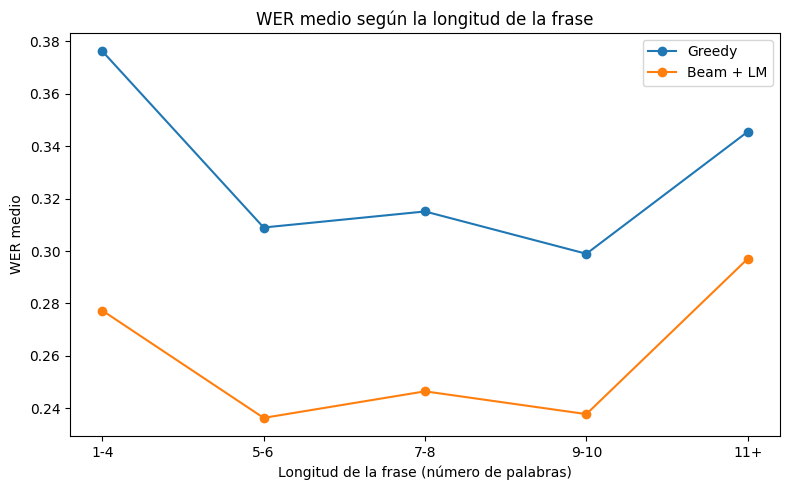

In [12]:
# WER vs longitud en palabras
import matplotlib.pyplot as plt

plot_df = length_summary_words.copy()

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(plot_df["word_len_bin"].astype(str), plot_df["mean_wer_greedy"], marker="o", label="Greedy")
ax.plot(plot_df["word_len_bin"].astype(str), plot_df["mean_wer_lm"], marker="o", label="Beam + LM")
ax.set_xlabel("Longitud de la frase (número de palabras)")
ax.set_ylabel("WER medio")
ax.set_title("WER medio según la longitud de la frase")
ax.legend()
plt.tight_layout()
plt.savefig("./img_text/WER_medio_vs_longitud_de_frase.png")
plt.show()

,char_len_bin,n_samples,mean_cer_greedy,mean_cer_lm,mean_wer_greedy,mean_wer_lm
0,1-20,144,0.135491,0.114356,0.298958,0.206597
1,21-30,413,0.136477,0.110519,0.291814,0.203638
2,31-40,483,0.147894,0.128131,0.318376,0.255198
3,41-50,309,0.156558,0.137214,0.349882,0.284758
4,51+,77,0.207595,0.188313,0.428025,0.380381


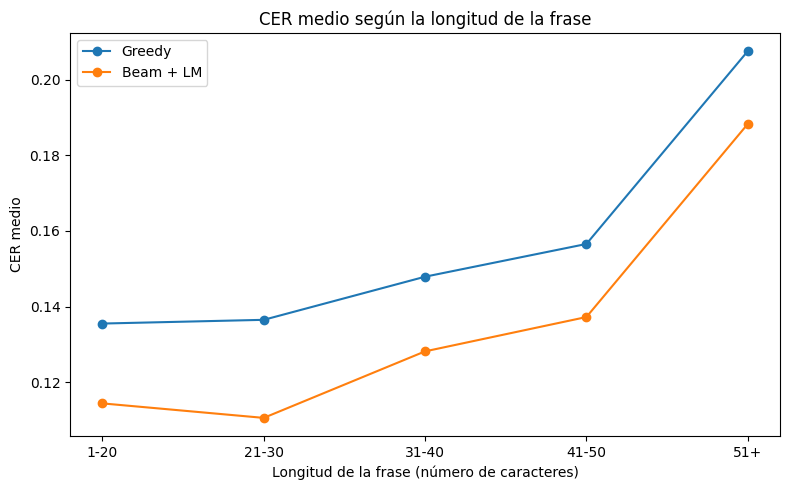

In [13]:
# CER vs longitud de caracteres
length_summary_chars = (
    df_text
    .groupby("char_len_bin", observed=False)
    .agg(
        n_samples=("true_text_val", "count"),
        mean_cer_greedy=("cer_greedy", "mean"),
        mean_cer_lm=("cer_beam_lm", "mean"),
        mean_wer_greedy=("wer_greedy", "mean"),
        mean_wer_lm=("wer_beam_lm", "mean"),
    )
    .reset_index()
)

display(length_summary_chars)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(length_summary_chars["char_len_bin"].astype(str), length_summary_chars["mean_cer_greedy"], marker="o", label="Greedy")
ax.plot(length_summary_chars["char_len_bin"].astype(str), length_summary_chars["mean_cer_lm"], marker="o", label="Beam + LM")
ax.set_xlabel("Longitud de la frase (número de caracteres)")
ax.set_ylabel("CER medio")
ax.set_title("CER medio según la longitud de la frase")
ax.legend()
plt.tight_layout()
plt.savefig("./img_text/CER_medio_vs_longitud_de_frase.png")
plt.show()

In [14]:
from scipy.stats import spearmanr

corr_word_wer = spearmanr(df_text["true_word_len"], df_text["wer_beam_lm"], nan_policy="omit")
corr_char_cer = spearmanr(df_text["true_char_len"], df_text["cer_beam_lm"], nan_policy="omit")

print("Spearman longitud-palabras vs WER beam+LM:", corr_word_wer)
print("Spearman longitud-caracteres vs CER beam+LM:", corr_char_cer)

Spearman longitud-palabras vs WER beam+LM: SignificanceResult(statistic=np.float64(0.03245854559554535), pvalue=np.float64(0.2205899271690529))
Spearman longitud-caracteres vs CER beam+LM: SignificanceResult(statistic=np.float64(0.19278868978957775), pvalue=np.float64(2.0921922336924717e-13))


### Error por sesión


In [15]:
session_summary = (
    df_text
    .groupby("day_index", dropna=False)
    .agg(
        n_samples=("true_text_val", "count"),
        mean_wer_greedy=("wer_greedy", "mean"),
        mean_wer_lm=("wer_beam_lm", "mean"),
        mean_cer_greedy=("cer_greedy", "mean"),
        mean_cer_lm=("cer_beam_lm", "mean"),
    )
    .reset_index()
)

session_summary["delta_wer"] = session_summary["mean_wer_lm"] - session_summary["mean_wer_greedy"]
session_summary["delta_cer"] = session_summary["mean_cer_lm"] - session_summary["mean_cer_greedy"]

display(session_summary.sort_values("mean_wer_lm"))

,day_index,n_samples,mean_wer_greedy,mean_wer_lm,mean_cer_greedy,mean_cer_lm,delta_wer,delta_cer
17,18,15,0.062857,0.022857,0.044524,0.031905,-0.040000,-0.012619
18,19,25,0.093079,0.030825,0.038909,0.019871,-0.062254,-0.019039
19,20,20,0.085079,0.038175,0.025778,0.011408,-0.046905,-0.014371
5,6,49,0.195983,0.102146,0.075484,0.047502,-0.093837,-0.027982
23,24,25,0.214937,0.121762,0.074299,0.047591,-0.093175,-0.026708
22,23,50,0.247222,0.137048,0.089741,0.063258,-0.110175,-0.026483
33,37,46,0.231690,0.151056,0.107041,0.081102,-0.080635,-0.025939
2,3,48,0.219563,0.161311,0.091247,0.082126,-0.058252,-0.009122
10,11,36,0.246032,0.171781,0.099724,0.076532,-0.074250,-0.023192
3,4,25,0.254671,0.181351,0.102495,0.088480,-0.073320,-0.014015


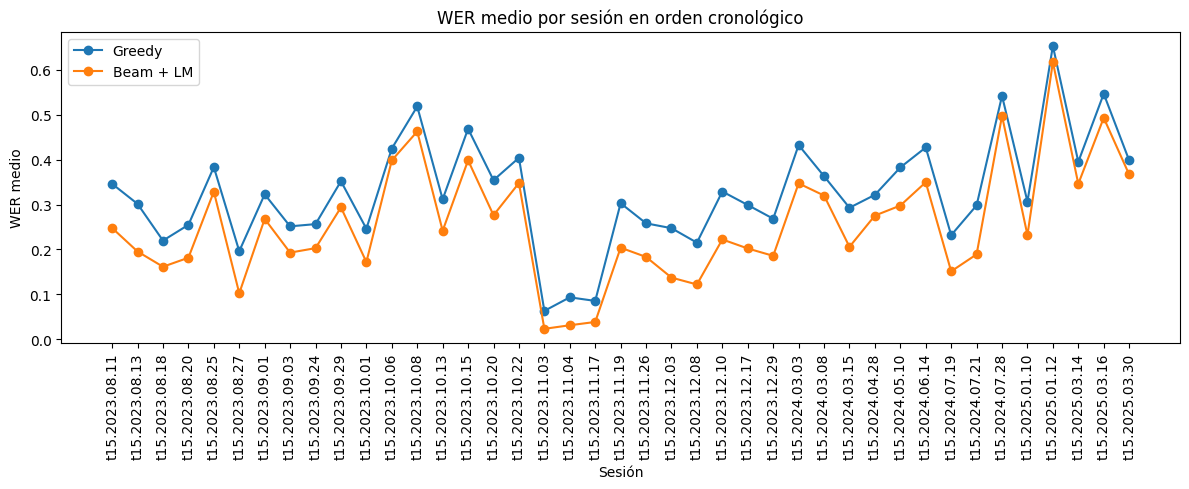

In [ ]:
# Lista de sesiones en el mismo orden usado en el entrenamiento
sessions = [
    "t15.2023.08.11",
    "t15.2023.08.13",
    "t15.2023.08.18",
    "t15.2023.08.20",
    "t15.2023.08.25",
    "t15.2023.08.27",
    "t15.2023.09.01",
    "t15.2023.09.03",
    "t15.2023.09.24",
    "t15.2023.09.29",
    "t15.2023.10.01",
    "t15.2023.10.06",
    "t15.2023.10.08",
    "t15.2023.10.13",
    "t15.2023.10.15",
    "t15.2023.10.20",
    "t15.2023.10.22",
    "t15.2023.11.03",
    "t15.2023.11.04",
    "t15.2023.11.17",
    "t15.2023.11.19",
    "t15.2023.11.26",
    "t15.2023.12.03",
    "t15.2023.12.08",
    "t15.2023.12.10",
    "t15.2023.12.17",
    "t15.2023.12.29",
    "t15.2024.02.25",
    "t15.2024.03.03",
    "t15.2024.03.08",
    "t15.2024.03.15",
    "t15.2024.03.17",
    "t15.2024.04.25",
    "t15.2024.04.28",
    "t15.2024.05.10",
    "t15.2024.06.14",
    "t15.2024.07.19",
    "t15.2024.07.21",
    "t15.2024.07.28",
    "t15.2025.01.10",
    "t15.2025.01.12",
    "t15.2025.03.14",
    "t15.2025.03.16",
    "t15.2025.03.30",
    "t15.2025.04.13",
]

day_to_session = {i + 1: s for i, s in enumerate(sessions)}

# Resumen por sesión
session_summary = (
    df_text
    .groupby("day_index", as_index=False)
    .agg(
        mean_wer_greedy=("wer_greedy", "mean"),
        mean_wer_lm=("wer_beam_lm", "mean")
    )
)

# Añadir nombre y fecha de sesión
plot_df = session_summary.copy()
plot_df["session_name"] = plot_df["day_index"].map(day_to_session)

plot_df["session_date"] = pd.to_datetime(
    plot_df["session_name"].str.extract(r"(\d{4}\.\d{2}\.\d{2})")[0],
    format="%Y.%m.%d"
)

# Orden cronológico
plot_df = plot_df.sort_values("session_date").copy()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(plot_df["session_name"], plot_df["mean_wer_greedy"], marker="o", label="Greedy")
ax.plot(plot_df["session_name"], plot_df["mean_wer_lm"], marker="o", label="Beam + LM")

ax.set_xlabel("Sesión")
ax.set_ylabel("WER medio")
ax.set_title("WER medio por sesión en orden cronológico")
ax.legend()

plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig("./img_text/WER_medio_por_sesion_cronologico.png", dpi=300, bbox_inches="tight")
plt.show()

### Tipos de error: inserciones, borrados y sustituciones


In [17]:
def levenshtein_ops(ref_tokens, hyp_tokens):
    n, m = len(ref_tokens), len(hyp_tokens)
    dp = [[0]*(m+1) for _ in range(n+1)]
    back = [[None]*(m+1) for _ in range(n+1)]

    for i in range(n+1):
        dp[i][0] = i
        if i > 0:
            back[i][0] = "del"
    for j in range(m+1):
        dp[0][j] = j
        if j > 0:
            back[0][j] = "ins"

    for i in range(1, n+1):
        for j in range(1, m+1):
            if ref_tokens[i-1] == hyp_tokens[j-1]:
                dp[i][j] = dp[i-1][j-1]
                back[i][j] = "ok"
            else:
                sub = dp[i-1][j-1] + 1
                dele = dp[i-1][j] + 1
                ins = dp[i][j-1] + 1
                best = min(sub, dele, ins)
                dp[i][j] = best
                if best == sub:
                    back[i][j] = "sub"
                elif best == dele:
                    back[i][j] = "del"
                else:
                    back[i][j] = "ins"

    i, j = n, m
    ops = []
    while i > 0 or j > 0:
        op = back[i][j]
        ops.append(op)
        if op in ("ok", "sub"):
            i -= 1
            j -= 1
        elif op == "del":
            i -= 1
        elif op == "ins":
            j -= 1
        else:
            break

    ops.reverse()
    return {
        "ok": ops.count("ok"),
        "sub": ops.count("sub"),
        "del": ops.count("del"),
        "ins": ops.count("ins"),
    }

In [18]:
def word_error_ops(ref, hyp):
    ref_tokens = str(ref).split()
    hyp_tokens = str(hyp).split()
    return levenshtein_ops(ref_tokens, hyp_tokens)

ops_rows = []
for _, row in df_text.iterrows():
    greedy_ops = word_error_ops(row["true_text_val"], row["greedy_text"])
    lm_ops = word_error_ops(row["true_text_val"], row["beam_lm_text"])

    ops_rows.append({
        "greedy_sub": greedy_ops["sub"],
        "greedy_del": greedy_ops["del"],
        "greedy_ins": greedy_ops["ins"],
        "lm_sub": lm_ops["sub"],
        "lm_del": lm_ops["del"],
        "lm_ins": lm_ops["ins"],
    })

df_ops = pd.DataFrame(ops_rows)

ops_summary = pd.DataFrame({
    "Modo": ["Greedy", "Beam + LM"],
    "Sustituciones": [df_ops["greedy_sub"].sum(), df_ops["lm_sub"].sum()],
    "Borrados": [df_ops["greedy_del"].sum(), df_ops["lm_del"].sum()],
    "Inserciones": [df_ops["greedy_ins"].sum(), df_ops["lm_ins"].sum()],
})

display(ops_summary)

,Modo,Sustituciones,Borrados,Inserciones
0,Greedy,3914,64,27
1,Beam + LM,3443,62,28


### Frecuencia de palabras y longitud de palabra

In [19]:
from collections import Counter

all_ref_words = []
for txt in df_text["true_text_val"]:
    all_ref_words.extend(str(txt).split())

word_freq = Counter(all_ref_words)

df_word_freq = pd.DataFrame({
    "word": list(word_freq.keys()),
    "freq": list(word_freq.values())
}).sort_values("freq", ascending=False)

display(df_word_freq.head(20))

,word,freq
3,the,408
76,i,275
21,a,263
34,to,249
0,you,178
72,of,170
45,is,136
39,in,131
12,it,114
93,that,107


In [20]:
# Tasa de error por palabra
def word_level_match_stats(df, pred_col="beam_lm_text"):
    rows = []
    for _, row in df.iterrows():
        ref_words = str(row["true_text_val"]).split()
        hyp_words = str(row[pred_col]).split()

        for w in ref_words:
            rows.append({
                "word": w,
                "word_len": len(w),
                "freq_in_corpus": word_freq[w],
                "present_in_pred": int(w in hyp_words),
            })
    return pd.DataFrame(rows)

df_word_stats = word_level_match_stats(df_text, pred_col="beam_lm_text")
display(df_word_stats.head())

,word,word_len,freq_in_corpus,present_in_pred
0,you,3,178,1
1,can,3,28,1
2,see,3,17,1
3,the,3,408,1
4,code,4,1,0


In [21]:
# Error segúnu frecuencia y longitud de palabra
df_word_stats["freq_bin"] = pd.cut(
    df_word_stats["freq_in_corpus"],
    bins=[0, 1, 2, 5, 10, 1000],
    labels=["1", "2", "3-5", "6-10", "11+"],
    include_lowest=True
)

df_word_stats["len_bin"] = pd.cut(
    df_word_stats["word_len"],
    bins=[0, 4, 6, 8, 20],
    labels=["1-4", "5-6", "7-8", "9+"],
    include_lowest=True
)

freq_summary = (
    df_word_stats
    .groupby("freq_bin", observed=False)
    .agg(
        n_words=("word", "count"),
        accuracy=("present_in_pred", "mean")
    )
    .reset_index()
)

len_summary = (
    df_word_stats
    .groupby("len_bin", observed=False)
    .agg(
        n_words=("word", "count"),
        accuracy=("present_in_pred", "mean")
    )
    .reset_index()
)

display(freq_summary)
display(len_summary)

,freq_bin,n_words,accuracy
0,1,1544,0.126943
1,2,654,0.298165
2,3-5,1174,0.463373
3,6-10,777,0.588160
4,11+,5296,0.862915


,len_bin,n_words,accuracy
0,1-4,5844,0.827858
1,5-6,2160,0.378241
2,7-8,939,0.251331
3,9+,502,0.141434


### Selección de ejemplos

In [22]:
# mejores ejemplos
best_examples = df_text.sort_values(["wer_beam_lm", "cer_beam_lm"]).head(10)
display(best_examples[[
    "true_text_val", "greedy_text", "beam_lm_text",
    "wer_greedy", "wer_beam_lm", "cer_greedy", "cer_beam_lm"
]])

,true_text_val,greedy_text,beam_lm_text,wer_greedy,wer_beam_lm,cer_greedy,cer_beam_lm
12,one thing or the other.,one think or the other,one thing or the other,0.200000,0.0,0.045455,0.0
17,i guess i like to take care of it.,i juss i like to take care of it,i guess i like to take care of it,0.111111,0.0,0.060606,0.0
20,you just really can't tell what's going to hap...,you just really cant tell wats going to happe,you just really cant tell whats going to happen,0.222222,0.0,0.042553,0.0
21,and who is in charge of making that decision?,and who is in choirge of making that decision,and who is in charge of making that decision,0.111111,0.0,0.045455,0.0
22,not for the job i have now.,not for the job i have now,not for the job i have now,0.000000,0.0,0.000000,0.0
25,i'm trying to think.,ime trying to thin,im trying to think,0.500000,0.0,0.111111,0.0
28,if you look back.,if you look back,if you look back,0.000000,0.0,0.000000,0.0
31,"for me, i had no choice but to move.",for me i had no choice but to move,for me i had no choice but to move,0.000000,0.0,0.000000,0.0
32,then it's twice as hard.,then its twece as hord,then its twice as hard,0.400000,0.0,0.090909,0.0
33,i can't really complain.,i cant really complane,i cant really complain,0.250000,0.0,0.090909,0.0


In [23]:
# Peores ejemplos
worst_examples = df_text.sort_values(["wer_beam_lm", "cer_beam_lm"], ascending=False).head(10)
display(worst_examples[[
    "true_text_val", "greedy_text", "beam_lm_text",
    "wer_greedy", "wer_beam_lm", "cer_greedy", "cer_beam_lm"
]])

,true_text_val,greedy_text,beam_lm_text,wer_greedy,wer_beam_lm,cer_greedy,cer_beam_lm
9,woodworking mastery.,whet marking nestory,what making mestory,1.500000,1.5,0.473684,0.421053
1324,are you pleased with this decision?,leats thin thi eein,leats thin the eein,1.000000,1.0,0.647059,0.676471
242,zoology department.,oualoge depotd,oualoge depot,1.000000,1.0,0.555556,0.555556
1393,the two seats up front are empty.,they do sinces op rit are ar hoppe,they do sincs op it are a hope,1.000000,1.0,0.562500,0.531250
1061,an absolute certainty.,and ipturlut sertay,and iturlut setay,1.000000,1.0,0.523810,0.523810
553,a vegetable garden.,he figuabl corded,he viguabl corded,1.000000,1.0,0.555556,0.500000
1268,cars have come down in price significantly.,cours of come dot it prose sountiitut,cours of com dot it prose sotilitut,0.857143,1.0,0.476190,0.500000
1332,not too long ago.,nad to lakago,mod to lakago,1.000000,1.0,0.437500,0.437500
480,grandparents engagement throw stage,grabaos enjamman through state,grabaros enjamman through state,1.000000,1.0,0.457143,0.428571
39,employee benefits.,employing benesents,employing binsets,1.000000,1.0,0.352941,0.411765


In [24]:
# Mejora sustancial del LM
lm_best_fix = df_text.sort_values("delta_wer_greedy_to_lm").head(10)
display(lm_best_fix[[
    "true_text_val", "greedy_text", "beam_text", "beam_lm_text",
    "wer_greedy", "wer_beam", "wer_beam_lm"
]])

,true_text_val,greedy_text,beam_text,beam_lm_text,wer_greedy,wer_beam,wer_beam_lm
1210,employment income.,empoyment encome,empoyment encome,employment income,1.000000,1.000000,0.000000
744,real rough type camping.,weall rogh tipe camping,weal rogh tipe camping,real rough type camping,0.750000,0.750000,0.000000
829,seventy awful years.,siventy owful years,siventy owful years,seventy awful years,0.666667,0.666667,0.000000
25,i'm trying to think.,ime trying to thin,ive trying to thin,im trying to think,0.500000,0.500000,0.000000
68,he didn't just say.,he didn just soy,he didn just soy,he didnt just say,0.500000,0.500000,0.000000
71,in the previous version.,in the privious vesion,in the privious vesion,in the previous version,0.500000,0.500000,0.000000
452,i'm concerned.,im soncined,im soncirned,im concerned,0.500000,0.500000,0.000000
1396,keep it clean please.,keep at lean please,keep at lean please,keep it clean please,0.500000,0.500000,0.000000
83,it was written many years ago.,it was twenten miny yearsago,it was twenten miny yearsago,it was twenten many years ago,0.666667,0.666667,0.166667
1137,you get the point.,sou geet the point,sou geet the point,you get the point,0.500000,0.500000,0.000000


In [25]:
# Empeoramiento por parte del lm 
lm_worst_fix = df_text.sort_values("delta_wer_greedy_to_lm", ascending=False).head(10)
display(lm_worst_fix[[
    "true_text_val", "greedy_text", "beam_text", "beam_lm_text",
    "wer_greedy", "wer_beam", "wer_beam_lm"
]])

,true_text_val,greedy_text,beam_text,beam_lm_text,wer_greedy,wer_beam,wer_beam_lm
700,thank york catch along set.,thank york catch along saite,thank york catch along saite,thank yourk catch along site,0.200000,0.200000,0.400000
1105,it's up by green bay.,its op by freaed bay,its op by freaed bay,its op by fred by,0.400000,0.400000,0.600000
872,i think it's caused a lot.,i think its cost a lot,i think its cost a lot,think its cost a lot,0.166667,0.166667,0.333333
816,the morning sun light is white.,the moning sun lot is whight,the moning sun lot is whight,the moning sin lot is whit,0.500000,0.500000,0.666667
1268,cars have come down in price significantly.,cours of come dot it prose sountiitut,cours of come dot it prose sontilitut,cours of com dot it prose sotilitut,0.857143,0.857143,1.000000
1116,did you see it the other night?,did you see it the olbo night,did you see it the olbo night,did you see it the abo right,0.142857,0.142857,0.285714
1400,"eat slowly, chew well, and enjoy the meal.",it slolly tru well and agroy they mell,it slolly tru well and a groy they mell,it slolly true well and a gry they mell,0.750000,0.875000,0.875000
1399,i don't know what you think about that.,i dont know want the think apout that,i dont know want the think apout that,i dont kno wat the think apout that,0.375000,0.375000,0.500000
1374,you'd think that it was a private school.,youd think atthan it was a frivanct school,youd think atthan it was a frivanct school,youd think at than it was a frivant school,0.250000,0.250000,0.375000
1253,they're doing a lot of good research here.,theh dove a not it dot fuesons here,theh dove at not it dot fuesons here,theh dove at not it dont fusons here,0.750000,0.875000,0.875000


### Palabras más confundidas


In [26]:
from collections import Counter
import pandas as pd
import numpy as np

def levenshtein_alignment(ref_tokens, hyp_tokens):
    n, m = len(ref_tokens), len(hyp_tokens)
    dp = [[0] * (m + 1) for _ in range(n + 1)]
    back = [[None] * (m + 1) for _ in range(n + 1)]

    for i in range(n + 1):
        dp[i][0] = i
        if i > 0:
            back[i][0] = "del"
    for j in range(m + 1):
        dp[0][j] = j
        if j > 0:
            back[0][j] = "ins"

    for i in range(1, n + 1):
        for j in range(1, m + 1):
            if ref_tokens[i - 1] == hyp_tokens[j - 1]:
                dp[i][j] = dp[i - 1][j - 1]
                back[i][j] = "ok"
            else:
                sub = dp[i - 1][j - 1] + 1
                dele = dp[i - 1][j] + 1
                ins = dp[i][j - 1] + 1
                best = min(sub, dele, ins)
                dp[i][j] = best

                # prioridad: sustitución, borrado, inserción
                if best == sub:
                    back[i][j] = "sub"
                elif best == dele:
                    back[i][j] = "del"
                else:
                    back[i][j] = "ins"

    i, j = n, m
    alignment = []

    while i > 0 or j > 0:
        op = back[i][j]

        if op == "ok":
            alignment.append(("ok", ref_tokens[i - 1], hyp_tokens[j - 1]))
            i -= 1
            j -= 1
        elif op == "sub":
            alignment.append(("sub", ref_tokens[i - 1], hyp_tokens[j - 1]))
            i -= 1
            j -= 1
        elif op == "del":
            alignment.append(("del", ref_tokens[i - 1], None))
            i -= 1
        elif op == "ins":
            alignment.append(("ins", None, hyp_tokens[j - 1]))
            j -= 1
        else:
            break

    alignment.reverse()
    return alignment


def extract_word_substitutions(df, ref_col="true_text_val", hyp_col="beam_lm_text"):
    rows = []

    for idx, row in df.iterrows():
        ref_tokens = str(row[ref_col]).split()
        hyp_tokens = str(row[hyp_col]).split()

        alignment = levenshtein_alignment(ref_tokens, hyp_tokens)

        for op, ref_tok, hyp_tok in alignment:
            if op == "sub":
                rows.append({
                    "row_idx": idx,
                    "ref_word": ref_tok,
                    "hyp_word": hyp_tok,
                    "ref_len": len(ref_tok) if ref_tok is not None else None,
                    "hyp_len": len(hyp_tok) if hyp_tok is not None else None,
                })

    return pd.DataFrame(rows)

In [27]:
df_subs_lm = extract_word_substitutions(df_text, ref_col="true_text_val", hyp_col="beam_lm_text")
df_subs_greedy = extract_word_substitutions(df_text, ref_col="true_text_val", hyp_col="greedy_text")

print("Sustituciones beam+LM:", df_subs_lm.shape)
print("Sustituciones greedy:", df_subs_greedy.shape)

confusions_lm = (
    df_subs_lm
    .groupby(["ref_word", "hyp_word"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
)

confusions_greedy = (
    df_subs_greedy
    .groupby(["ref_word", "hyp_word"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
)

display(confusions_lm.head(20))

Sustituciones beam+LM: (3443, 5)
Sustituciones greedy: (3914, 5)


,ref_word,hyp_word,count
0,it's,its,60
1,don't,dont,48
2,it.,it,31
3,that's,thats,31
4,i'm,im,28
5,that.,that,26
6,here.,here,19
7,there.,there,19
8,them.,them,15
9,this.,this,14


In [28]:
top_conf_compare = (
    confusions_lm.rename(columns={"count": "count_lm"})
    .merge(
        confusions_greedy.rename(columns={"count": "count_greedy"}),
        on=["ref_word", "hyp_word"],
        how="outer"
    )
    .fillna(0)
)

top_conf_compare["count_lm"] = top_conf_compare["count_lm"].astype(int)
top_conf_compare["count_greedy"] = top_conf_compare["count_greedy"].astype(int)
top_conf_compare["delta_lm_minus_greedy"] = top_conf_compare["count_lm"] - top_conf_compare["count_greedy"]

top_conf_compare = top_conf_compare.sort_values(
    ["count_lm", "count_greedy"],
    ascending=False
).reset_index(drop=True)

display(top_conf_compare.head(25))

,ref_word,hyp_word,count_lm,count_greedy,delta_lm_minus_greedy
0,it's,its,60,59,1
1,don't,dont,48,46,2
2,that's,thats,31,32,-1
3,it.,it,31,30,1
4,i'm,im,28,26,2
5,that.,that,26,26,0
6,here.,here,19,19,0
7,there.,there,19,19,0
8,them.,them,15,15,0
9,this.,this,14,13,1


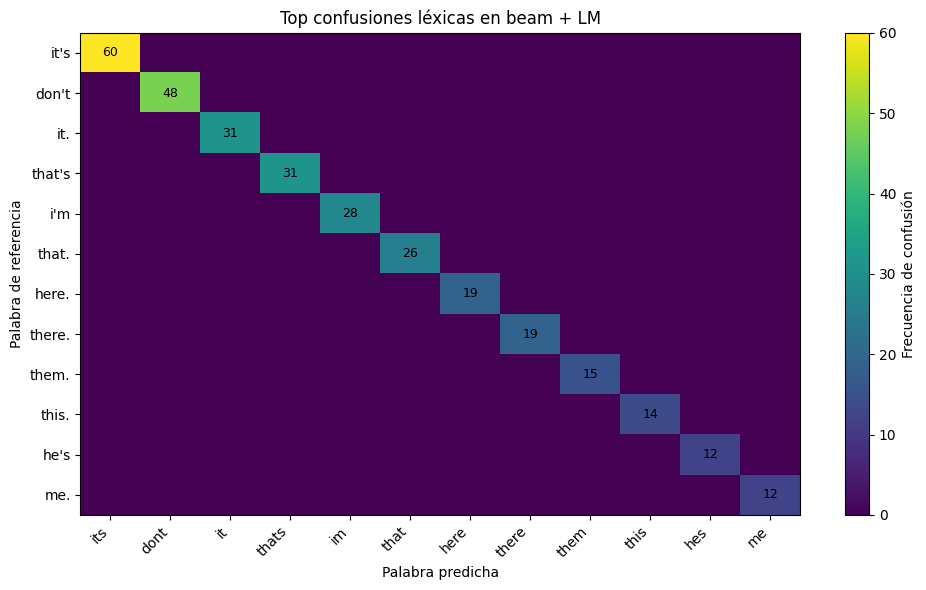

In [29]:
import matplotlib.pyplot as plt

def plot_top_confusion_heatmap(confusions_df, top_n=12, title="Top confusiones léxicas"):
    top_df = confusions_df.head(top_n).copy()

    ref_words = list(top_df["ref_word"].unique())
    hyp_words = list(top_df["hyp_word"].unique())

    mat = pd.DataFrame(
        0,
        index=ref_words,
        columns=hyp_words,
        dtype=int
    )

    for _, row in top_df.iterrows():
        mat.loc[row["ref_word"], row["hyp_word"]] = row["count"]

    fig, ax = plt.subplots(figsize=(10, 6))
    im = ax.imshow(mat.values, aspect="auto", interpolation="nearest")

    ax.set_xticks(np.arange(len(mat.columns)))
    ax.set_yticks(np.arange(len(mat.index)))
    ax.set_xticklabels(mat.columns, rotation=45, ha="right")
    ax.set_yticklabels(mat.index)

    ax.set_xlabel("Palabra predicha")
    ax.set_ylabel("Palabra de referencia")
    ax.set_title(title)

    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            val = mat.iloc[i, j]
            if val != 0:
                ax.text(j, i, str(val), ha="center", va="center", fontsize=9)

    fig.colorbar(im, ax=ax, label="Frecuencia de confusión")
    plt.tight_layout()
    plt.savefig("./img_text/CM_top_confusiones.png")
    plt.show()

    return mat

mat_lm = plot_top_confusion_heatmap(
    confusions_lm,
    top_n=12,
    title="Top confusiones léxicas en beam + LM"
)

In [30]:
top_ref_confusions = (
    df_subs_lm
    .groupby("ref_word")
    .agg(
        total_confusions=("hyp_word", "count"),
        n_pred_words=("hyp_word", "nunique")
    )
    .sort_values("total_confusions", ascending=False)
    .reset_index()
)

display(top_ref_confusions.head(20))

,ref_word,total_confusions,n_pred_words
0,it's,63,4
1,don't,51,4
2,it.,33,2
3,that's,32,2
4,i'm,28,1
5,that.,27,2
6,here.,21,3
7,there.,19,1
8,this.,15,2
9,them.,15,1


In [31]:
top_ref_to_hyp = (
    df_subs_lm
    .groupby(["ref_word", "hyp_word"])
    .size()
    .reset_index(name="count")
    .sort_values(["ref_word", "count"], ascending=[True, False])
    .reset_index(drop=True)
)

display(top_ref_to_hyp.head(30))

,ref_word,hyp_word,count
0,a,he,4
1,a,i,4
2,a,at,1
3,a,is,1
4,a,its,1
5,able,visionable,1
6,about,abort,1
7,about,aboy,1
8,about,apout,1
9,about.,about,1


### Coincidencia exacta

In [38]:
import re

def normalize_text_for_match(text):
    if text is None:
        return ""
    text = str(text).lower().strip()
    text = text.replace(">", "")
    text = re.sub(r"[^\w\s]", "", text)  # quita puntuación
    text = " ".join(text.split())
    return text

df_text["true_text_norm"] = df_text["true_text_val"].apply(normalize_text_for_match)
df_text["greedy_text_norm"] = df_text["greedy_text"].apply(normalize_text_for_match)
df_text["beam_text_norm"] = df_text["beam_text"].apply(normalize_text_for_match)
df_text["beam_lm_text_norm"] = df_text["beam_lm_text"].apply(normalize_text_for_match)

df_text["exact_match_greedy_norm"] = (
    df_text["true_text_norm"] == df_text["greedy_text_norm"]
).astype(int)

df_text["exact_match_lm_norm"] = (
    df_text["true_text_norm"] == df_text["beam_lm_text_norm"]
).astype(int)

print("Exact match greedy normalizado:", df_text["exact_match_greedy_norm"].mean())
print("Exact match beam+LM normalizado:", df_text["exact_match_lm_norm"].mean())



Exact match greedy normalizado: 0.14095371669004209
Exact match beam+LM normalizado: 0.2924263674614306


### Tabla final


In [34]:
text_summary = {
    "CER_greedy_mean": df_text["cer_greedy"].mean(),
    "CER_beam_mean": df_text["cer_beam"].mean(),
    "CER_beam_lm_mean": df_text["cer_beam_lm"].mean(),
    "WER_greedy_mean": df_text["wer_greedy"].mean(),
    "WER_beam_mean": df_text["wer_beam"].mean(),
    "WER_beam_lm_mean": df_text["wer_beam_lm"].mean(),
    "Exact_match_greedy": df_text["exact_match_greedy"].mean(),
    "Exact_match_beam_lm": df_text["exact_match_lm"].mean(),
    "LM_improves_WER_samples": int((df_text["delta_wer_beam_to_lm"] < 0).sum()),
    "LM_worsens_WER_samples": int((df_text["delta_wer_beam_to_lm"] > 0).sum()),
}
pd.Series(text_summary)

CER_greedy_mean              0.148436
CER_beam_mean                0.146367
CER_beam_lm_mean             0.126857
WER_greedy_mean              0.321470
WER_beam_mean                0.318916
WER_beam_lm_mean             0.248522
Exact_match_greedy           0.000000
Exact_match_beam_lm          0.000000
LM_improves_WER_samples    549.000000
LM_worsens_WER_samples      10.000000
dtype: float64